<a href="https://colab.research.google.com/github/AkhilGummadi7/Fake-job-posting-detection-/blob/main/Fake-Job-Posting-Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.svm import LinearSVC

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import time
import warnings
warnings.filterwarnings("ignore")

import re
import string

from wordcloud import WordCloud

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

plt.style.use("ggplot")
sns.set(font_scale=1.0)

print("Libraries Imported Successfully")

Libraries Imported Successfully


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## **Load Dataset**

In [ ]:
df = pd.read_csv('/content/fake1_final.csv')



In [ ]:

df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,employee_count
0,1,Call Center Representative I,"US, NC, Charlotte",CSR,30000-45000,As the industry’s largest supply contracting c...,Call Center Rep - Oversees the service deliver...,High School DiplomaExcellent communication ski...,FULL- TIME BENEFITS,0,1,1,Full-time,Associate,High School or equivalent,Consumer Services,Customer Service,1,183
1,2,Community Manager,"GR, I, Acharnes",Online PR,20000-24000,Mindworks interactive is one of the fastest gr...,One of the biggest Social Media Teams in Greec...,Excellent understanding and use of social medi...,"Why Work for MindworksWe dream big. Together, ...",0,1,1,Full-time,Mid-Senior level,Unspecified,Marketing and Advertising,Advertising,0,190
2,3,Technical Support Associate,"US, IL, Chicago",Technical Support,25000-30000,AboutPPD Partners provides English and Spanish...,We are looking to hire motivated people to add...,Our entry-level Technical Support Reps answer ...,"We offer a comprehensive benefits package, 401...",0,1,0,Full-time,Entry level,High School or equivalent,Consumer Services,Other,0,104
3,4,Acquisition Marketing Manager,"US, NY, New York",Marketing,75000-85000,FeedMe is an online multimedia food network co...,The acquisition marketing manager role is for ...,3-5 Years of Experience in:User acquisition fo...,$75-85k per year + equity3 first months are tr...,0,1,0,Other,Director,Bachelor's Degree,Internet,Marketing,0,177
4,5,Payroll Clerk,"US, GA,",Account,35000-40000,Basil Lifecare Pvt. Ltd. is a Wellness &amp; P...,We are seeking a full time Payroll Clerk to ma...,• High school diploma or equivalent• Excellent...,We offer a competitive salary and benefits pac...,0,0,0,Full-time,Entry level,High School or equivalent,Hospital & Health Care,Financial Analyst,1,140


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1404 entries, 0 to 1403
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               1404 non-null   int64 
 1   title                1404 non-null   object
 2   location             1404 non-null   object
 3   department           1404 non-null   object
 4   salary_range         1404 non-null   object
 5   company_profile      1404 non-null   object
 6   description          1404 non-null   object
 7   requirements         1404 non-null   object
 8   benefits             1404 non-null   object
 9   telecommuting        1404 non-null   int64 
 10  has_company_logo     1404 non-null   int64 
 11  has_questions        1404 non-null   int64 
 12  employment_type      1404 non-null   object
 13  required_experience  1404 non-null   object
 14  required_education   1404 non-null   object
 15  industry             1404 non-null   object
 16  functi

In [ ]:
print(df.shape)

(1404, 19)


In [ ]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 1404
Number of Columns : 19


In [ ]:
for col in df.columns:
    print(col)

job_id
title
location
department
salary_range
company_profile
description
requirements
benefits
telecommuting
has_company_logo
has_questions
employment_type
required_experience
required_education
industry
function
fraudulent
employee_count


In [ ]:
datatype = pd.DataFrame(df.dtypes, columns=["Data Type"])
print(datatype)

                    Data Type
job_id                  int64
title                  object
location               object
department             object
salary_range           object
company_profile        object
description            object
requirements           object
benefits               object
telecommuting           int64
has_company_logo        int64
has_questions           int64
employment_type        object
required_experience    object
required_education     object
industry               object
function               object
fraudulent              int64
employee_count          int64


## **Handling Missing Values**

In [ ]:


missing_values = df.isnull().sum()

print(missing_values)

job_id                 0
title                  0
location               0
department             0
salary_range           0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
employee_count         0
dtype: int64


In [ ]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percent.round(2)
})

missing_df.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage
job_id,0,0.0
title,0,0.0
location,0,0.0
department,0,0.0
salary_range,0,0.0
company_profile,0,0.0
description,0,0.0
requirements,0,0.0
benefits,0,0.0
telecommuting,0,0.0


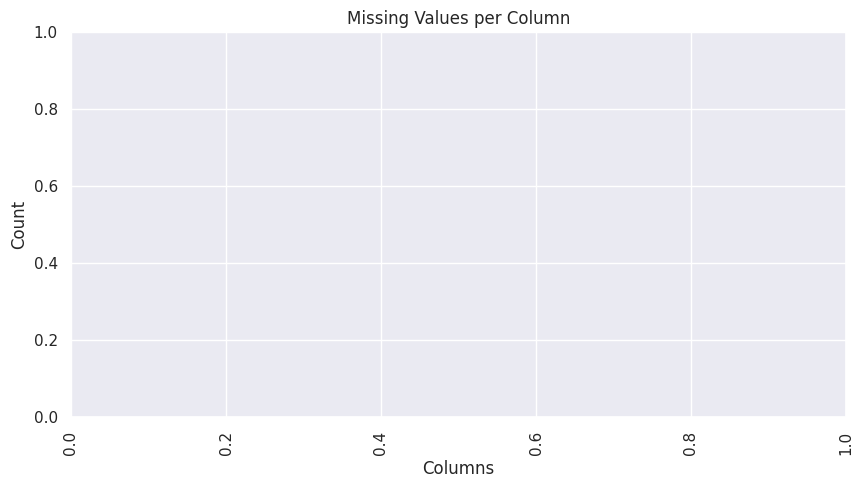

In [ ]:
missing_df = missing_df[missing_df["Missing Values"]>0]

plt.figure(figsize=(10,5))

sns.barplot(
    x=missing_df.index,
    y=missing_df["Missing Values"]
)

plt.xticks(rotation=90)

plt.title("Missing Values per Column")

plt.ylabel("Count")

plt.xlabel("Columns")

plt.show()

## **Handling Duplicates**

In [ ]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows :", duplicate_count)

Duplicate Rows : 0


In [ ]:
duplicate_percentage = duplicate_count/len(df)*100

print(f"Duplicate Percentage : {duplicate_percentage:.2f}%")

Duplicate Percentage : 0.00%


In [ ]:
if duplicate_count > 0:
    df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates")

print(df.shape)

Dataset Shape After Removing Duplicates
(1404, 19)


In [ ]:
unique_df = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

unique_df.sort_values("Unique Values")

,Column,Unique Values
10,has_company_logo,2
11,has_questions,2
9,telecommuting,2
17,fraudulent,2
12,employment_type,5
13,required_experience,7
14,required_education,10
16,function,36
15,industry,68
18,employee_count,101


In [ ]:
for col in df.columns:

    print("="*50)

    print(col)

    print(df[col].nunique())

job_id
1404
title
615
location
217
department
243
salary_range
300
company_profile
198
description
693
requirements
641
benefits
526
telecommuting
2
has_company_logo
2
has_questions
2
employment_type
5
required_experience
7
required_education
10
industry
68
function
36
fraudulent
2
employee_count
101


In [ ]:
target_column = "fraudulent"

print(df[target_column].value_counts())

fraudulent
1    702
0    702
Name: count, dtype: int64


In [ ]:
print(df[target_column].value_counts(normalize=True)*100)

fraudulent
1    50.0
0    50.0
Name: proportion, dtype: float64


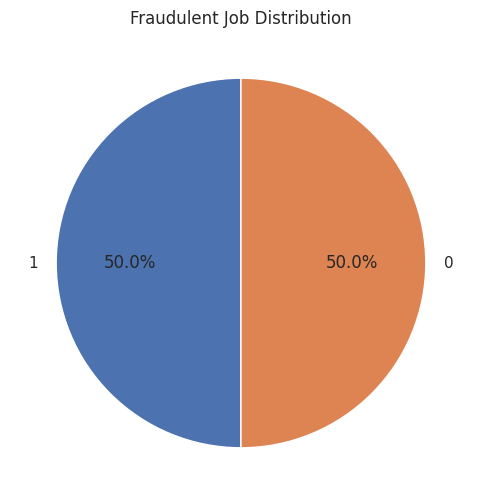

In [ ]:
plt.figure(figsize=(6,6))

df[target_column].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Fraudulent Job Distribution")

plt.show()

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

numerical_cols

Index(['job_id', 'telecommuting', 'has_company_logo', 'has_questions',
       'fraudulent', 'employee_count'],
      dtype='object')

In [ ]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
job_id,1404.0,702.500000,405.444201,1.0,351.75,702.5,1053.25,1404.0
telecommuting,1404.0,0.125356,0.331240,0.0,0.00,0.0,0.00,1.0
has_company_logo,1404.0,0.962963,0.188920,0.0,1.00,1.0,1.00,1.0
has_questions,1404.0,0.690171,0.462588,0.0,0.00,1.0,1.00,1.0
fraudulent,1404.0,0.500000,0.500178,0.0,0.00,0.5,1.00,1.0
employee_count,1404.0,150.146724,29.452183,100.0,125.00,150.0,176.00,200.0


In [ ]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols

Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function'],
      dtype='object')

In [ ]:
for col in categorical_cols:

    print("="*60)

    print(col)

    print(df[col].value_counts().head(10))

title
title
Customer Service Representative    106
Plant Operator                      27
Sales Representative                26
Call Center Representative I        26
IC&E Technician                     24
UST Testing Technician              23
UST Testing Technician II           22
UST Testing Technician III          22
CALL CENTER REP                     22
Payroll Clerk                       21
Name: count, dtype: int64
location
location
US, TX, AUSTIN             110
US, CA, Bakersfield         99
US, TX, Austin              79
GB, LND, London             75
US, TX, DALLAS              68
US, CA, Bakersfield, CA     45
US, MD, Baltimore           41
NZ, N, Auckland             40
US, NY, New York            33
US, FL, Jacksonville        27
Name: count, dtype: int64
department
department
Sales                 118
Oil & Energy          118
Customer Service       86
Engineering            65
Sales and Research     46
Marketing              44
Oil & Energy           44
CALL CENTER   

In [ ]:
report = pd.DataFrame({

    "Data Type":df.dtypes,

    "Missing":df.isnull().sum(),

    "Unique":df.nunique(),

    "Duplicates":df.duplicated().sum()

})

report

,Data Type,Missing,Unique,Duplicates
job_id,int64,0,1404,0
title,object,0,615,0
location,object,0,217,0
department,object,0,243,0
salary_range,object,0,300,0
company_profile,object,0,198,0
description,object,0,693,0
requirements,object,0,641,0
benefits,object,0,526,0
telecommuting,int64,0,2,0


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
df['title'] = df['title'].fillna('')
df['company_profile'] = df['company_profile'].fillna('')
df['description'] = df['description'].fillna('')
df['requirements'] = df['requirements'].fillna('')
df['benefits'] = df['benefits'].fillna('')

df['combined_text'] = df['title'] + ' ' + df['company_profile'] + ' ' + df['description'] + ' ' + df['requirements'] + ' ' + df['benefits']

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.90
)

X_tfidf = tfidf.fit_transform(df["combined_text"])

print(X_tfidf.shape)

(1404, 5000)


## **Count Vectorizer**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.90
)

X_cv = cv.fit_transform(df["combined_text"])

print(X_cv.shape)

(1404, 5000)


In [ ]:
comparison = pd.DataFrame({
    "Vectorizer":["TF-IDF","CountVectorizer"],
    "Features":[X_tfidf.shape[1],X_cv.shape[1]],
    "Samples":[X_tfidf.shape[0],X_cv.shape[0]]
})

comparison

,Vectorizer,Features,Samples
0,TF-IDF,5000,1404
1,CountVectorizer,5000,1404


In [ ]:
X = X_tfidf

y = df["fraudulent"]

print("Feature Matrix :", X.shape)

print("Target Shape :", y.shape)

Feature Matrix : (1404, 5000)
Target Shape : (1404,)


In [ ]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:100])

['000' '000 for' '000 per' '000 vha' '10' '10 years' '100' '100 years'
 '1000' '12' '12 months' '15' '15 kv' '18' '1871' '20' '20 insurance'
 '2000' '2005' '2007' '2007 to' '2012' '2012 where' '2014' '24' '25' '260'
 '260 stores' '30' '35' '3d' '40' '40 billion' '400' '401' '401 plan'
 '401k' '401khealth' '401khealth insurancepaid' '50' '500' '500 000' '60'
 '65' '65 000' '75' '90' '90 seconds' 'abilities' 'abilities high'
 'ability' 'ability to' 'able' 'able to' 'about' 'about the' 'about us'
 'about what' 'above' 'acceptable' 'acceptable off' 'access' 'access to'
 'accessbasic' 'accessbasic computer' 'accion' 'accion has' 'accion story'
 'accion success' 'accommodation' 'accomplish' 'accordance'
 'accordance with' 'according' 'according to' 'account'
 'account executive' 'account executives' 'account per' 'accountability'
 'accounting' 'accounts' 'accuracy' 'accuracy and' 'accurate'
 'accurate and' 'accurately' 'accurately and' 'achieve' 'achieve wellness'
 'achieve your' 'achieving'

## **Employment Type Plot**

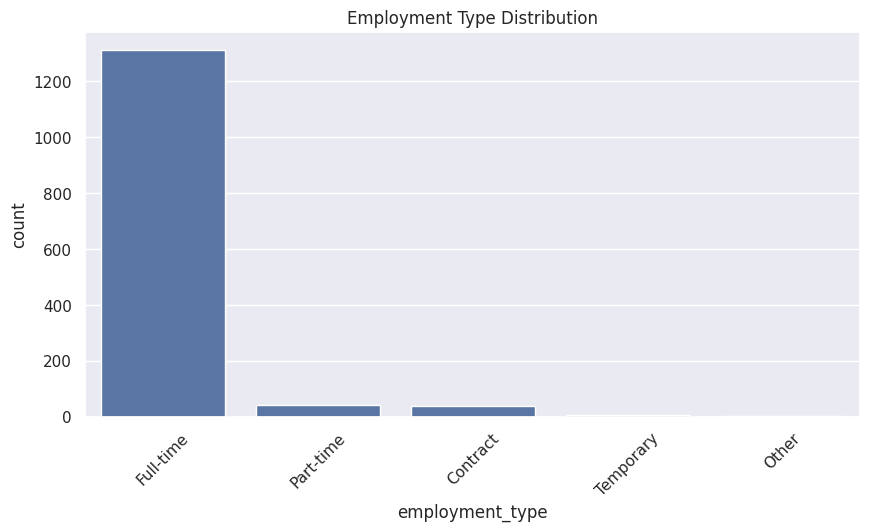

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="employment_type",
    order=df["employment_type"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Employment Type Distribution")

plt.show()

## **Experiecnce Plot**

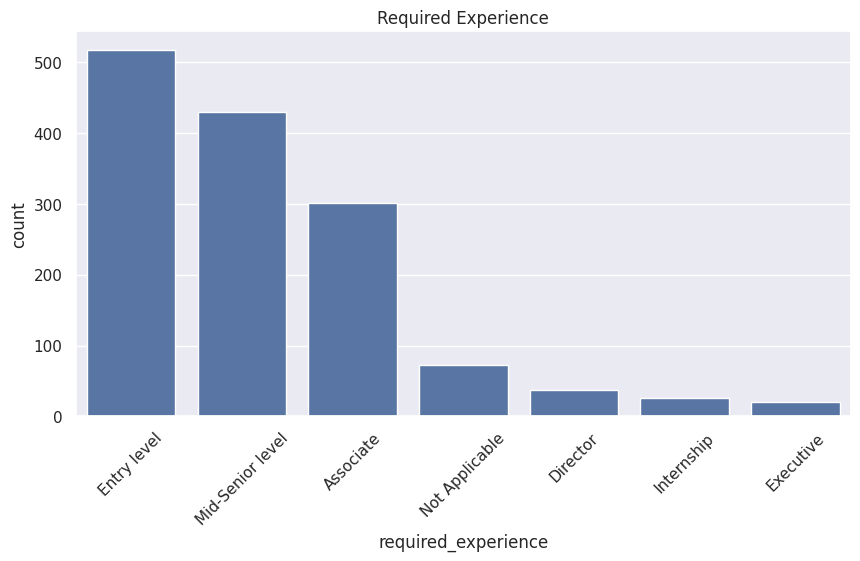

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="required_experience",
    order=df["required_experience"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Required Experience")

plt.show()

## **Job Sectors**

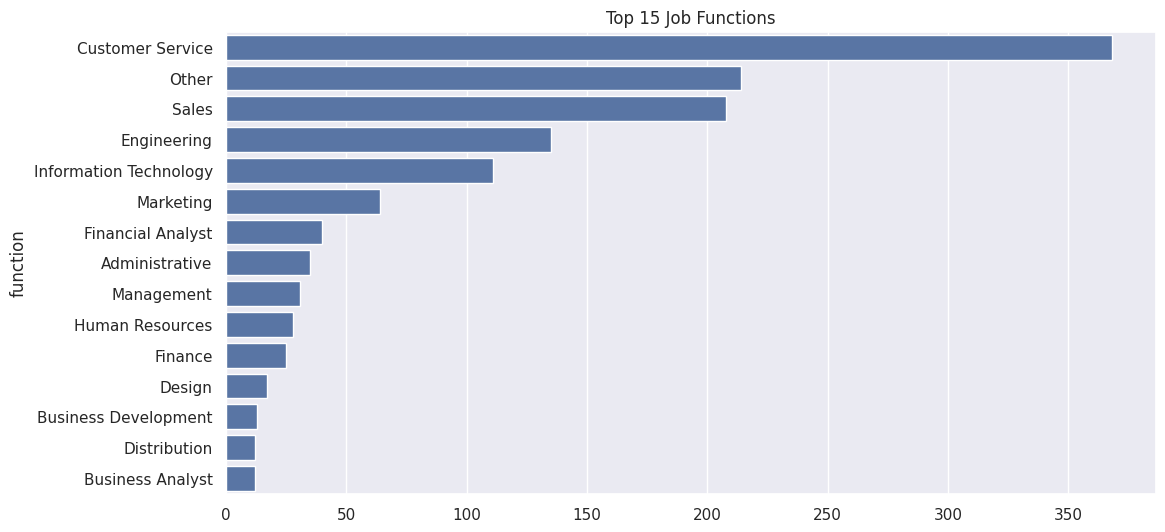

In [ ]:
plt.figure(figsize=(12,6))

top_function = df["function"].value_counts().head(15)

sns.barplot(
    x=top_function.values,
    y=top_function.index
)

plt.title("Top 15 Job Functions")

plt.show()

## **Correlation Matrics Visualization**

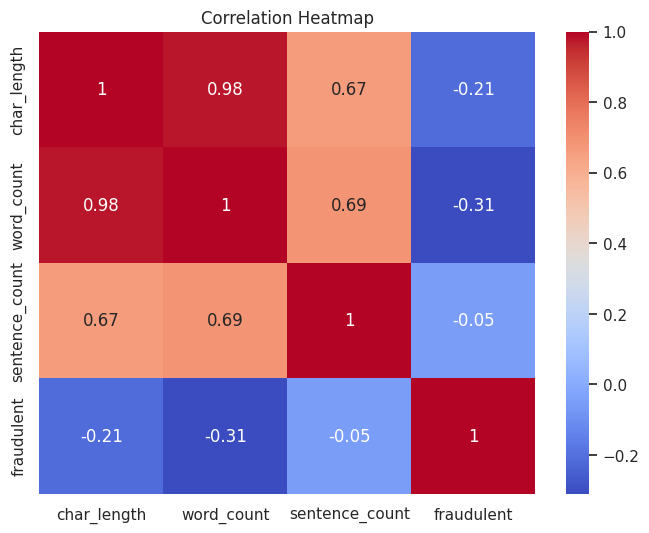

In [ ]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
df['char_length'] = df['combined_text'].apply(len)
df['word_count'] = df['combined_text'].apply(lambda x: len(x.split()))
df['sentence_count'] = df['combined_text'].apply(lambda x: len(nltk.sent_tokenize(x)))

numeric_columns = [
    "char_length",
    "word_count",
    "sentence_count",
    "fraudulent"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## **Shape of Dataset After Data Analysis**

In [ ]:


print(f"Dataset Shape : {df.shape}")
print(f"TF-IDF Matrix : {X_tfidf.shape}")
print(f"CountVectorizer Matrix : {X_cv.shape}")


Dataset Shape : (1404, 23)
TF-IDF Matrix : (1404, 5000)
CountVectorizer Matrix : (1404, 5000)


## **Test Train Split**

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

NameError: name 'train_test_split' is not defined

## **Logistic Regression**

In [ ]:
start=time.time()

lr=LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

end=time.time()

print("Training Time :",round(end-start,2),"seconds")

Training Time : 0.04 seconds


In [ ]:
lr_pred=lr.predict(X_test)

lr_acc=accuracy_score(y_test,lr_pred)

print("Accuracy :",lr_acc)

Accuracy : 0.99644128113879


## **Multinomial Naive Bayes**

In [ ]:
start=time.time()

nb=MultinomialNB()

nb.fit(X_train,y_train)

end=time.time()

print("Training Time :",round(end-start,2),"seconds")

Training Time : 0.01 seconds


In [ ]:
nb_pred=nb.predict(X_test)

nb_acc=accuracy_score(y_test,nb_pred)

print("Accuracy :",nb_acc)

Accuracy : 0.9822064056939501


## **Linear SVM**

In [ ]:
start=time.time()

svm=LinearSVC()

svm.fit(X_train,y_train)

end=time.time()

print("Training Time :",round(end-start,2),"seconds")

Training Time : 0.06 seconds


In [ ]:
svm_pred=svm.predict(X_test)

svm_acc=accuracy_score(y_test,svm_pred)

print("Accuracy :",svm_acc)

Accuracy : 0.99644128113879


## **Random Forest**

In [ ]:
start=time.time()

rf=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

end=time.time()

print("Training Time :",round(end-start,2),"seconds")

Training Time : 1.31 seconds


In [ ]:
rf_pred=rf.predict(X_test)

rf_acc=accuracy_score(y_test,rf_pred)

print("Accuracy :",rf_acc)

Accuracy : 1.0


##**Cross-Validation for Random Forest**



In [ ]:
start_cv = time.time()
rf_cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

end_cv = time.time()

print(f"Random Forest Cross-Validation Scores: {rf_cv_scores}")
print(f"Mean CV Accuracy: {np.mean(rf_cv_scores):.4f}")
print(f"CV Training Time: {round(end_cv - start_cv, 2)} seconds")

Random Forest Cross-Validation Scores: [1. 1. 1. 1. 1.]
Mean CV Accuracy: 1.0000
CV Training Time: 11.79 seconds


##**Confusion Matrix and Classification Report**



Confusion Matrix for Random Forest:


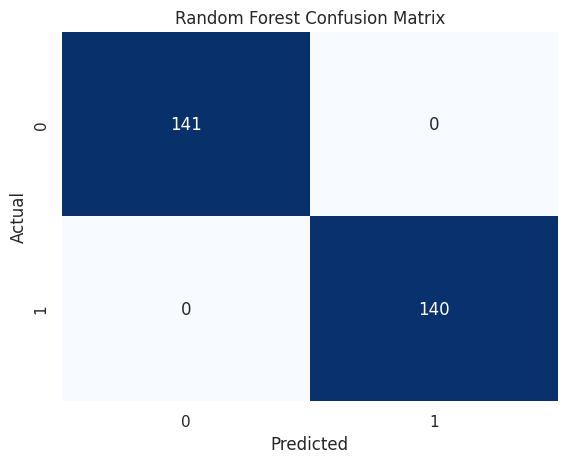


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       141
           1       1.00      1.00      1.00       140

    accuracy                           1.00       281
   macro avg       1.00      1.00      1.00       281
weighted avg       1.00      1.00      1.00       281



In [ ]:
print("Confusion Matrix for Random Forest:")
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

print("\nClassification Report for Random Forest:")
print(classification_report(y_test, rf_pred))

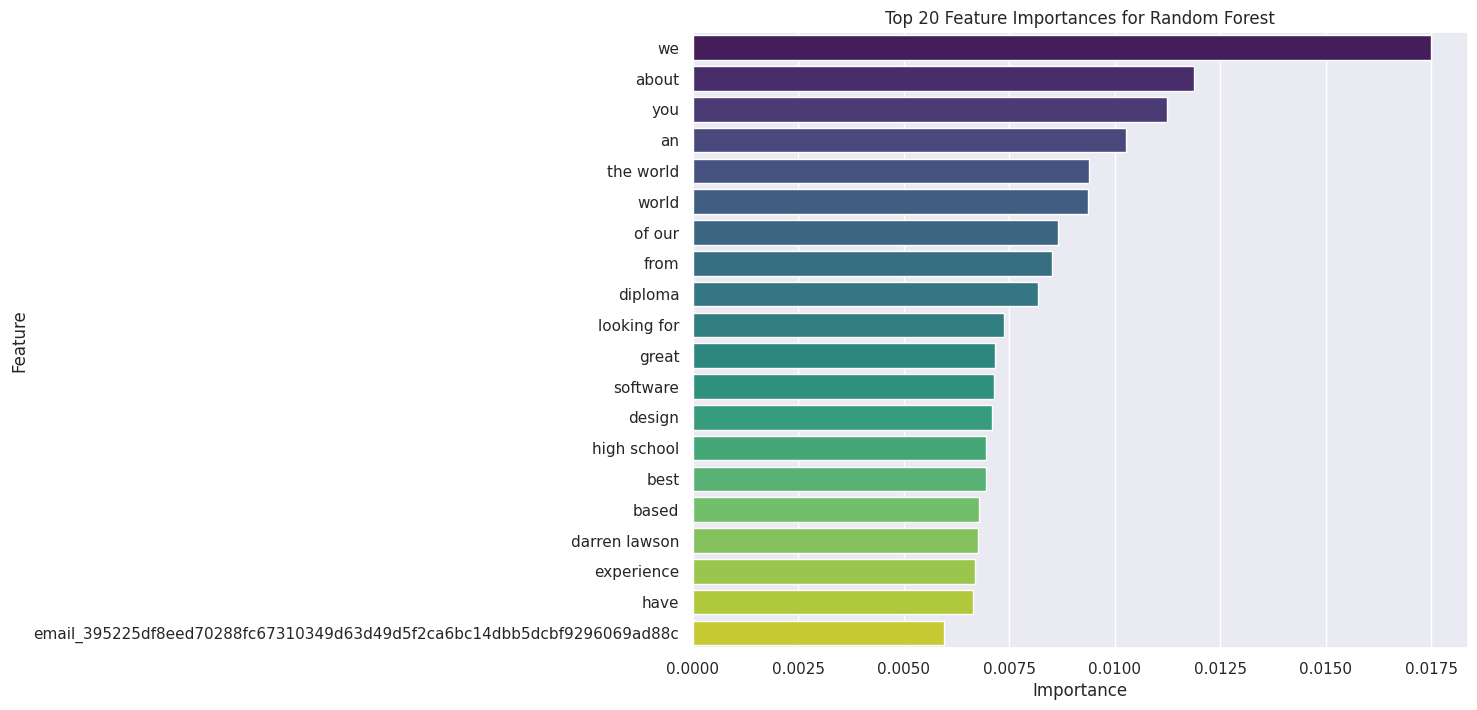

In [ ]:

importances = rf.feature_importances_
feature_names = tfidf.get_feature_names_out()
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})
N = 20  # Number of top features to display
top_n_features = feature_importance_df.sort_values(by='importance', ascending=False).head(N)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=top_n_features, palette='viridis')
plt.title(f'Top {N} Feature Importances for Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## **Extra Tree**

In [ ]:
start=time.time()

et=ExtraTreesClassifier(
    n_estimators=200,
    random_state=42
)

et.fit(X_train,y_train)

end=time.time()

print("Training Time :",round(end-start,2),"seconds")

Training Time : 0.66 seconds


In [ ]:
et_pred=et.predict(X_test)

et_acc=accuracy_score(y_test,et_pred)

print("Accuracy :",et_acc)d

Accuracy : 1.0


## **Comparing Initial Accuracy**

In [ ]:
comparison=pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "Random Forest",
        "Extra Trees"
    ],

    "Accuracy":[
        lr_acc,
        nb_acc,
        svm_acc,
        rf_acc,
        et_acc
    ]
})

comparison.sort_values("Accuracy",ascending=False)

,Model,Accuracy
4,Extra Trees,1.000000
3,Random Forest,1.000000
0,Logistic Regression,0.996441
2,Linear SVM,0.996441
1,Naive Bayes,0.982206


## **Accuracy Plot**

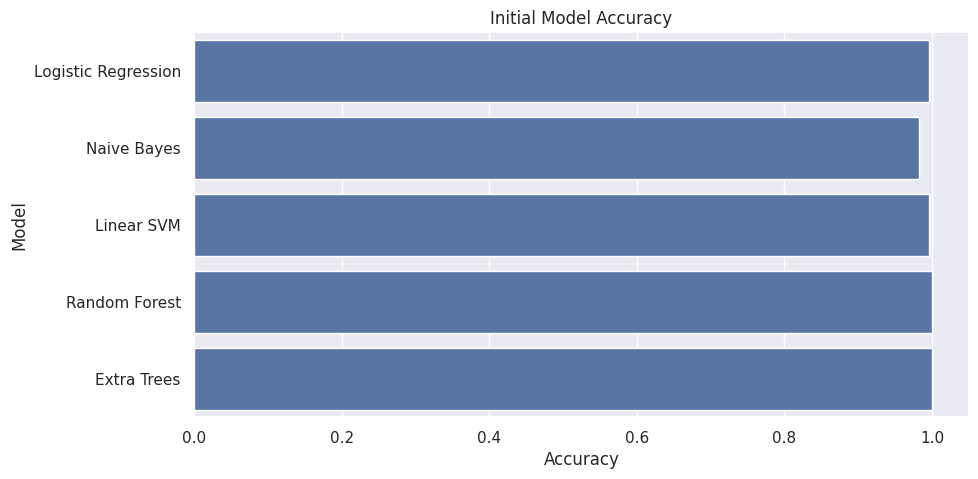

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison,
    x="Accuracy",
    y="Model"
)

plt.title("Initial Model Accuracy")

plt.show()

## **Logistic Regression Tuning**

In [ ]:
params={

    "C":[0.01,0.1,1,10],

    "solver":["liblinear","lbfgs"]
}

grid_lr=GridSearchCV(

    LogisticRegression(max_iter=1000),

    params,

    cv=5,

    scoring="accuracy",

    n_jobs=-1
)

grid_lr.fit(X_train,y_train)

print(grid_lr.best_params_)

print(grid_lr.best_score_)

{'C': 10, 'solver': 'liblinear'}
0.9982222222222223


## **Random Forest Tuning**

In [ ]:
rf_params={

    "n_estimators":[100,200],

    "max_depth":[10,20,None],

    "min_samples_split":[2,5]
}

grid_rf=GridSearchCV(

    RandomForestClassifier(random_state=42),

    rf_params,

    cv=5,

    scoring="accuracy",

    n_jobs=-1
)

grid_rf.fit(X_train,y_train)

print(grid_rf.best_params_)

print(grid_rf.best_score_)

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
0.9991111111111112


## **Linear SVM Tuning**

In [ ]:
svm_params={

    "C":[0.1,1,5,10]
}

grid_svm=GridSearchCV(

    LinearSVC(),

    svm_params,

    cv=5,

    scoring="accuracy",

    n_jobs=-1
)

grid_svm.fit(X_train,y_train)

print(grid_svm.best_params_)

print(grid_svm.best_score_)

{'C': 1}
0.9991111111111112


## **Best Models**

In [ ]:
best_lr =grid_lr.best_estimator_

best_rf =grid_rf.best_estimator_

best_svm =grid_svm.best_estimator_

## **Cross Validation**

In [ ]:
models={

    "Logistic Regression":best_lr,

    "Naive Bayes":nb,

    "Linear SVM":best_svm,

    "Random Forest":best_rf,

    "Extra Trees":et
}

scores=[]

for name,model in models.items():

    cv_score=cross_val_score(

        model,

        X,

        y,

        cv=5,

        scoring="accuracy"

    )

    print(name)

    print("Scores :",cv_score)

    print("Mean :",cv_score.mean())

    print()

    scores.append(cv_score.mean())

Logistic Regression
Scores : [1.         0.99644128 0.99644128 1.         1.        ]
Mean : 0.9985765124555159

Naive Bayes
Scores : [1.         0.98932384 0.97153025 0.97153025 0.98214286]
Mean : 0.9829054397559736

Linear SVM
Scores : [1.         0.99644128 0.99644128 1.         1.        ]
Mean : 0.9985765124555159

Random Forest
Scores : [1. 1. 1. 1. 1.]
Mean : 1.0

Extra Trees
Scores : [1. 1. 1. 1. 1.]
Mean : 1.0



## **Cross Validation Comparison**

In [ ]:
cv_results=pd.DataFrame({

    "Model":list(models.keys()),

    "Cross Validation Accuracy":scores

})

cv_results.sort_values(

    "Cross Validation Accuracy",

    ascending=False

)

,Model,Cross Validation Accuracy
4,Extra Trees,1.000000
3,Random Forest,1.000000
0,Logistic Regression,0.998577
2,Linear SVM,0.998577
1,Naive Bayes,0.982905


## **Viaualization**

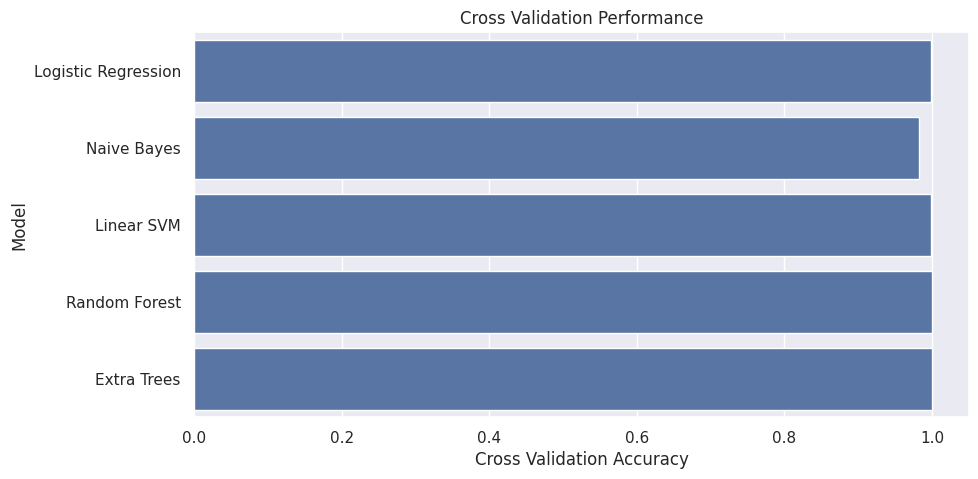

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=cv_results,

    x="Cross Validation Accuracy",

    y="Model"

)

plt.title("Cross Validation Performance")

plt.show()

## **Evaluate All Models**

In [ ]:

evaluation = []

models = {
    "Logistic Regression": best_lr,
    "Naive Bayes": nb,
    "Linear SVM": best_svm,
    "Random Forest": best_rf,
    "Extra Trees": et
}

for name, model in models.items():

    prediction = model.predict(X_test)

    evaluation.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction),
        "Recall": recall_score(y_test, prediction),
        "F1 Score": f1_score(y_test, prediction)
    })

results = pd.DataFrame(evaluation)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.996441,0.992908,1.000000,0.996441
1,Naive Bayes,0.982206,0.992701,0.971429,0.981949
2,Linear SVM,0.996441,0.992908,1.000000,0.996441
3,Random Forest,1.000000,1.000000,1.000000,1.000000
4,Extra Trees,1.000000,1.000000,1.000000,1.000000


## **Model Comparison**

In [ ]:
results.sort_values("Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
4,Extra Trees,1.000000,1.000000,1.000000,1.000000
3,Random Forest,1.000000,1.000000,1.000000,1.000000
0,Logistic Regression,0.996441,0.992908,1.000000,0.996441
2,Linear SVM,0.996441,0.992908,1.000000,0.996441
1,Naive Bayes,0.982206,0.992701,0.971429,0.981949


##**Accuracy Comparison Plot**

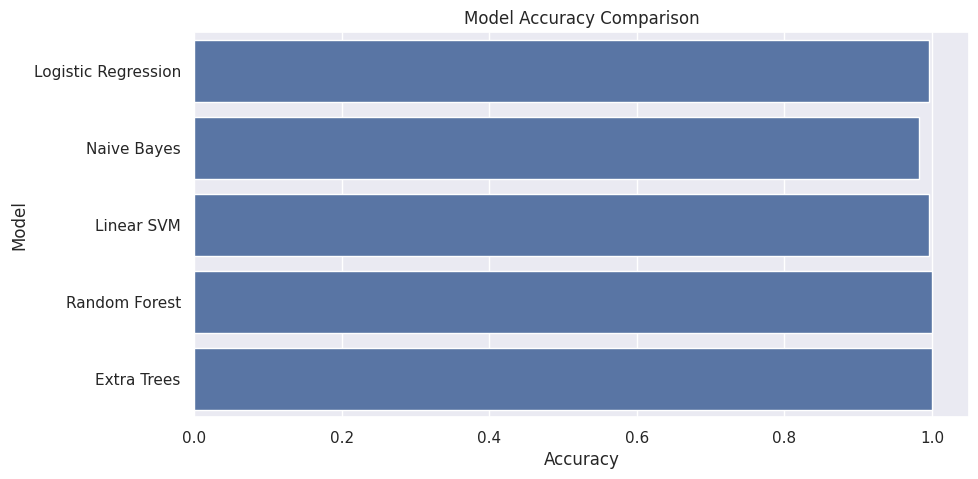

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Accuracy",
    y="Model"
)

plt.title("Model Accuracy Comparison")

plt.show()

## **F1 Score Comparison**

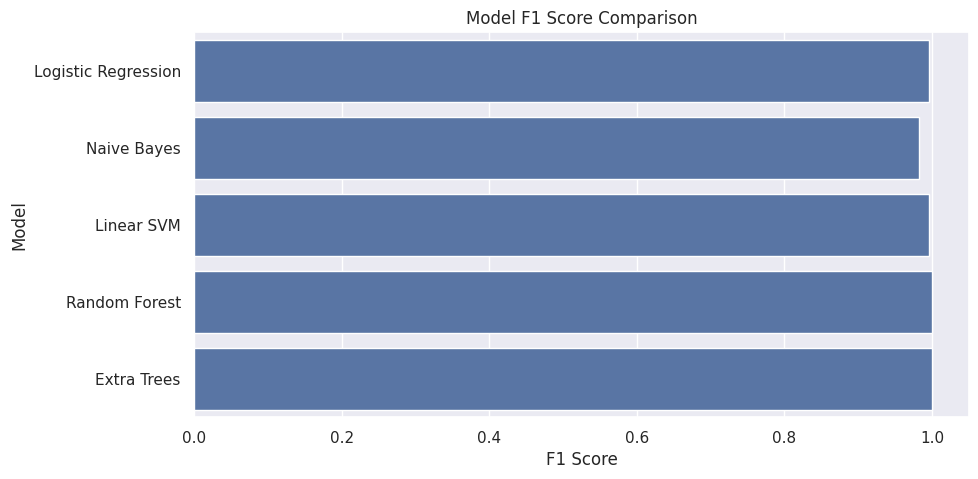

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="F1 Score",
    y="Model"
)

plt.title("Model F1 Score Comparison")

plt.show()

## **Best Model**

In [ ]:
best_model_name = results.sort_values(
    "Accuracy",
    ascending=False
).iloc[0]["Model"]

print(best_model_name)

Extra Trees


## **Confusion Matrix**

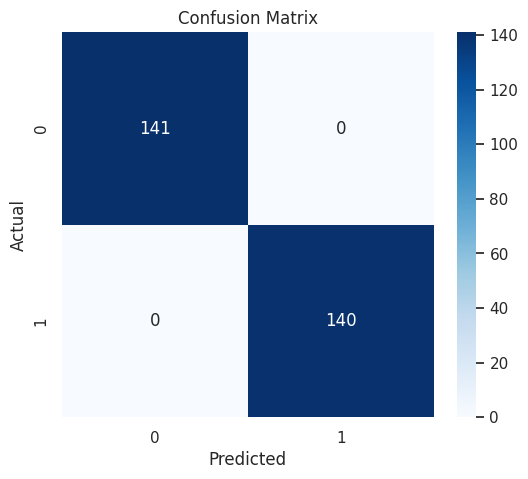

In [ ]:
best_model = models[best_model_name]

prediction = best_model.predict(X_test)

cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## **Classification Report**

In [ ]:
print(classification_report(
    y_test,
    prediction
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       141
           1       1.00      1.00      1.00       140

    accuracy                           1.00       281
   macro avg       1.00      1.00      1.00       281
weighted avg       1.00      1.00      1.00       281



## **ROC Curve**


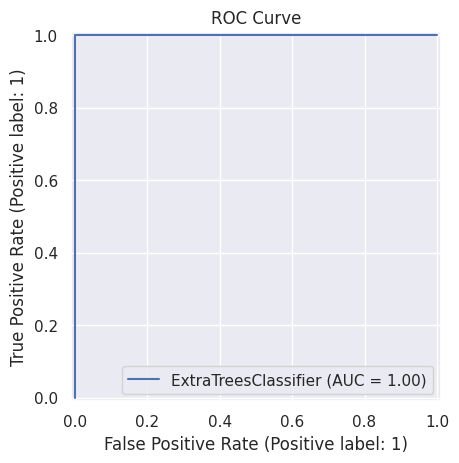

In [ ]:
from sklearn.metrics import RocCurveDisplay

if hasattr(best_model, "predict_proba"):

    RocCurveDisplay.from_estimator(
        best_model,
        X_test,
        y_test
    )

    plt.title("ROC Curve")

    plt.show()

# **Feature Importance**

In [ ]:
if best_model_name in ["Random Forest","Extra Trees"]:

    importance = best_model.feature_importances_

    features = tfidf.get_feature_names_out()

    importance_df = pd.DataFrame({

        "Feature":features,

        "Importance":importance

    })

    importance_df = importance_df.sort_values(
        "Importance",
        ascending=False
    )

    importance_df.head(20)

## **Error Analysis**

In [ ]:
errors = pd.DataFrame({

    "Actual":y_test.values,

    "Predicted":prediction

})

errors["Correct"] = errors["Actual"] == errors["Predicted"]

errors.head()

,Actual,Predicted,Correct
0,1,1,True
1,0,0,True
2,0,0,True
3,1,1,True
4,0,0,True


## **Prediction Function**

In [ ]:
def predict_job(
    title,
    company_profile,
    description,
    requirements,
    benefits,
    employment_type,
    required_experience,
    required_education,
    industry,
    function
):

    text = (
        title + " " +
        company_profile + " " +
        description + " " +
        requirements + " " +
        benefits + " " +
        employment_type + " " +
        required_experience + " " +
        required_education + " " +
        industry + " " +
        function
    )

    vector = tfidf.transform([text])

    prediction = best_model.predict(vector)[0]

    confidence = None

    if hasattr(best_model, "predict_proba"):

        confidence = np.max(
            best_model.predict_proba(vector)
        ) * 100

    if prediction == 1:

        print("Prediction : Fraudulent Job")

    else:

        print("Prediction : Genuine Job")

    if confidence is not None:

        print(f"Confidence : {confidence:.2f}%")

## **Prediction Sample**

In [ ]:
predict_job(

title="Senior Data Scientist",

company_profile="Google",

description="Looking for an experienced data scientist with Python ML SQL Deep Learning",

requirements="Python Machine Learning SQL TensorFlow",

benefits="Medical Insurance Bonus",

employment_type="Full-time",

required_experience="Mid-Senior level",

required_education="Bachelor's Degree",

industry="Information Technology",

function="Engineering"

)

Prediction : Genuine Job
Confidence : 97.00%
